In [37]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [38]:
import dask.dataframe as dd

train = dd.read_csv("/Users/abhimanyu/Downloads/train.csv",  names=["target", "review_heading", "review_body"],header=None )
test = dd.read_csv("/Users/abhimanyu/Downloads/test.csv",  names=["target", "review_heading", "review_body"],header=None)

In [39]:
train.tail()

,target,review_heading,review_body
41424,Item Name: ICE BREAKERS Spearmint Sugar Free M...,https://m.media-amazon.com/images/I/81p9PcPsff...,10.395
35537,"Item Name: Davidson's Organics, Vanilla Essenc...",https://m.media-amazon.com/images/I/51DDKoa+mb...,35.92
249971,Item Name: Jolly Rancher Hard Candy - Blue Ras...,https://m.media-amazon.com/images/I/91R2XCcpUf...,50.33
188322,Item Name: Nescafe Dolce Gusto Capsules - CARA...,https://m.media-amazon.com/images/I/51W40YU98+...,15.275
298504,Item Name: Pimenton de la Vera - Picante (2.47...,https://m.media-amazon.com/images/I/81dFnrP6C4...,28.240000000000002


In [40]:
train["review_body"].tail(5).tolist()


['10.395', '35.92', '50.33', '15.275', '28.240000000000002']

In [41]:
# Number of rows
n_rows = len(train)

# Number of columns
n_cols = len(train.columns)

print(f"Rows: {n_rows}, Columns: {n_cols}")


Rows: 75001, Columns: 3


In [42]:
train.isna().sum().compute()

target            0
review_heading    0
review_body       0
dtype: int64

In [43]:
# Replace NaN with "None"
train = train.fillna("None")

# Quick check
train.head()   # shows first 5 rows with NaNs replaced


,target,review_heading,review_body
sample_id,catalog_content,image_link,price
33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.890000000000001
198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.339999999999996


In [44]:
test.isna().sum().compute()

target            0
review_heading    0
review_body       0
dtype: int64

In [45]:
test = test.fillna("None")

In [46]:
dup_count = (train.shape[0] - train.drop_duplicates().shape[0]).compute()
print("Number of duplicate rows:", dup_count)



Number of duplicate rows: 13


In [47]:
import nltk
import re

# Download resources (run once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# 🔥 IMPORTANT FIX (preload wordnet for Dask)
from nltk.corpus import wordnet
wordnet.ensure_loaded()

# Import after loading
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Precompute (fast)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# -----------------------------
# Text cleaning function
# -----------------------------
def transform_text(text):
    if pd.isna(text) or text == "":
        return ""

    text = str(text).lower()

    # Extract words
    words = re.findall(r'\b[a-zA-Z0-9]+\b', text)

    # Lemmatization + stopword removal
    cleaned = [
        lemmatizer.lemmatize(w)
        for w in words
        if w not in stop_words
    ]

    return " ".join(cleaned)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/abhimanyu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/abhimanyu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/abhimanyu/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [48]:
train["transformed_review_heading"] = train["review_heading"].apply(
    transform_text, meta=("transformed_review_heading", "str")
)

train["transformed_review_body"] = train["review_body"].apply(
    transform_text, meta=("transformed_review_body", "str")
)

test["transformed_review_heading"] = test["review_heading"].apply(
    transform_text, meta=("transformed_review_heading", "str")
)

test["transformed_review_body"] = test["review_body"].apply(
    transform_text, meta=("transformed_review_body", "str")
)

In [49]:
 test.head()

,target,review_heading,review_body,transformed_review_heading,transformed_review_body
0,sample_id,catalog_content,image_link,,
1,100179,Item Name: Rani 14-Spice Eshamaya's Mango Chut...,https://m.media-amazon.com/images/I/71hoAn78AW...,item name rani 14 spice eshamaya mango chutney...,http medium amazon com image 71hoan78awl jpg
2,245611,Item Name: Natural MILK TEA Flavoring extract ...,https://m.media-amazon.com/images/I/61ex8NHCIj...,item name natural milk tea flavoring extract h...,http medium amazon com image 61ex8nhcijl jpg
3,146263,Item Name: Honey Filled Hard Candy - Bulk Pack...,https://m.media-amazon.com/images/I/61KCM61J8e...,item name honey filled hard candy bulk pack 2 ...,http medium amazon com image 61kcm61j8el jpg
4,95658,Item Name: Vlasic Snack'mm's Kosher Dill 16 Oz...,https://m.media-amazon.com/images/I/51Ex6uOH7y...,item name vlasic snack mm kosher dill 16 oz pa...,http medium amazon com image 51ex6uoh7yl jpg


In [50]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Word cloud for POSITIVE review headings (Dask-safe)
positive_reviews_pd = (
    train[train["target"] == 2]["transformed_review_heading"]
    .astype(str)
    .compute()
)

cleaned = [s for s in positive_reviews_pd.tolist() if s and s.strip() and s.lower() != "none"]
text = " ".join(cleaned)

if not text.strip():
    print("No positive review heading text available to generate a word cloud.")
else:
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Positive Amazon Reviews (Heading)")
    plt.show()

No positive review heading text available to generate a word cloud.


In [51]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Word cloud for POSITIVE review bodies (Dask-safe)
# NOTE: With Dask, always .compute() before joining strings.

positive_reviews_pd = (
    train[train["target"] == 2]["transformed_review_body"]
    .astype(str)
    .compute()
)

# Remove empty-like entries (including the placeholder "None")
cleaned = [s for s in positive_reviews_pd.tolist() if s and s.strip() and s.lower() != "none"]
text = " ".join(cleaned)

if not text.strip():
    print("No positive review body text available to generate a word cloud.")
else:
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Positive Amazon Reviews (Body)")
    plt.show()

No positive review body text available to generate a word cloud.


In [52]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Word cloud for NEGATIVE review headings (Dask-safe)
negative_reviews_pd = (
    train[train["target"] == 1]["transformed_review_heading"]
    .astype(str)
    .compute()
)

cleaned = [s for s in negative_reviews_pd.tolist() if s and s.strip() and s.lower() != "none"]
text = " ".join(cleaned)

if not text.strip():
    print("No negative review heading text available to generate a word cloud.")
else:
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Negative Amazon Reviews (Heading)")
    plt.show()

No negative review heading text available to generate a word cloud.


In [53]:
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import matplotlib.pyplot as plt

# Top words in POSITIVE review headings (Dask-safe)
positive_reviews_pd = (
    train[train["target"] == 2]["transformed_review_heading"]
    .astype(str)
    .compute()
)

cleaned = [s for s in positive_reviews_pd.tolist() if s and s.strip() and s.lower() != "none"]

if len(cleaned) == 0:
    print("No positive review heading text available for CountVectorizer.")
else:
    vectorizer = CountVectorizer(max_features=10, stop_words="english")
    X = vectorizer.fit_transform(cleaned)

    word_freq = X.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()

    sns.barplot(x=word_freq, y=words)
    plt.title("Top Words in Positive Reviews (Heading)")
    plt.tight_layout()
    plt.show()

No positive review heading text available for CountVectorizer.


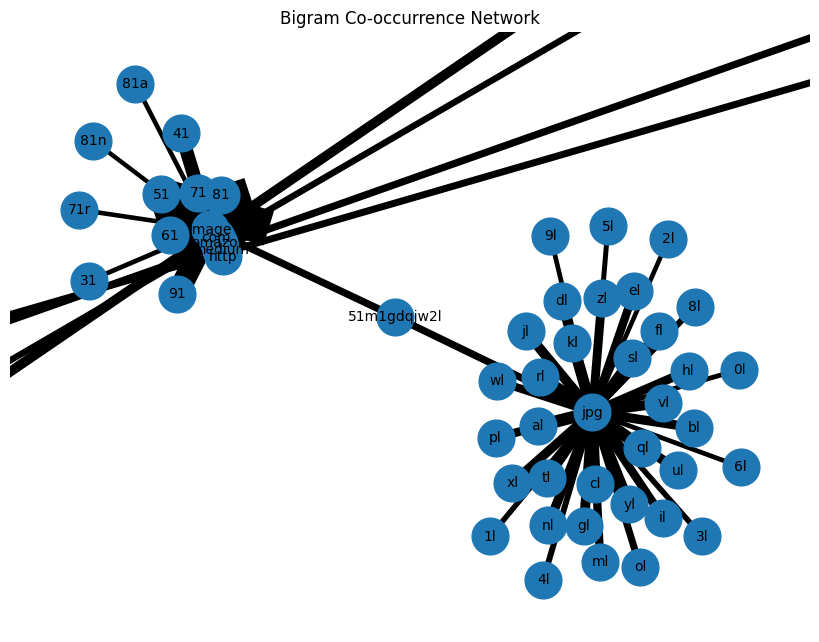

In [54]:
import networkx as nx
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), stop_words="english", max_features=50)
X = vectorizer.fit_transform(train["transformed_review_heading"].astype(str))
bigrams = vectorizer.get_feature_names_out()
freqs = X.sum(axis=0).A1

# Build graph
G = nx.Graph()
for bigram, freq in zip(bigrams, freqs):
    w1, w2 = bigram.split()
    G.add_edge(w1, w2, weight=freq)

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, k=0.5)
nx.draw(G, pos, with_labels=True, node_size=700, font_size=10, width=[d['weight']/10 for (_,_,d) in G.edges(data=True)])
plt.title("Bigram Co-occurrence Network")
plt.show()

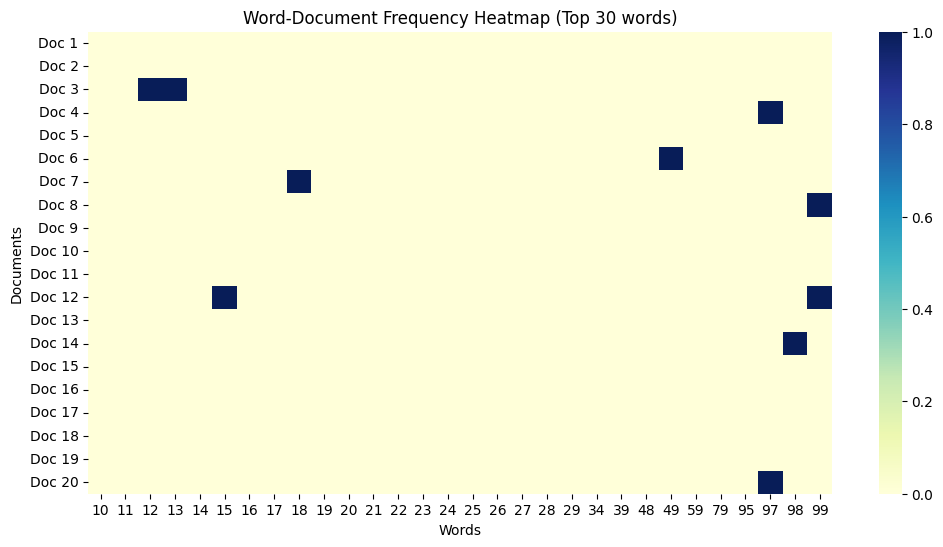

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Vectorize with top 15 words
vectorizer = CountVectorizer(max_features=30, stop_words="english")
X = vectorizer.fit_transform(train["transformed_review_body"].astype(str))

# Convert to array for plotting
matrix = X.toarray()[:20]  # first 20 documents for demo
words = vectorizer.get_feature_names_out()

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(matrix, cmap="YlGnBu", xticklabels=words, yticklabels=[f"Doc {i}" for i in range(1,21)])
plt.title("Word-Document Frequency Heatmap (Top 30 words)")
plt.xlabel("Words")
plt.ylabel("Documents")
plt.show()

In [56]:
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Positive reviews (heading)
# -----------------------------
positive_reviews_pd = (
    train[train["target"] == 2]["transformed_review_heading"]
    .astype(str)
    .compute()
)
positive_clean = [s for s in positive_reviews_pd.tolist() if s and s.strip() and s.lower() != "none"]

# -----------------------------
# Negative reviews (heading)
# -----------------------------
negative_reviews_pd = (
    train[train["target"] == 1]["transformed_review_heading"]
    .astype(str)
    .compute()
)
negative_clean = [s for s in negative_reviews_pd.tolist() if s and s.strip() and s.lower() != "none"]

if len(positive_clean) == 0 or len(negative_clean) == 0:
    print(
        "Not enough text to compare. "
        f"positive={len(positive_clean)} docs, negative={len(negative_clean)} docs"
    )
else:
    vectorizer_pos = CountVectorizer(max_features=10, stop_words="english")
    X_pos = vectorizer_pos.fit_transform(positive_clean)
    word_freq_pos = X_pos.sum(axis=0).A1
    words_pos = vectorizer_pos.get_feature_names_out()

    vectorizer_neg = CountVectorizer(max_features=10, stop_words="english")
    X_neg = vectorizer_neg.fit_transform(negative_clean)
    word_freq_neg = X_neg.sum(axis=0).A1
    words_neg = vectorizer_neg.get_feature_names_out()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.barplot(x=word_freq_pos, y=words_pos, ax=axes[0], palette="Greens_r")
    axes[0].set_title("Top Words in Positive Reviews (Heading)")

    sns.barplot(x=word_freq_neg, y=words_neg, ax=axes[1], palette="Reds_r")
    axes[1].set_title("Top Words in Negative Reviews (Heading)")

    plt.tight_layout()
    plt.show()

Not enough text to compare. positive=0 docs, negative=0 docs


In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Build combined text (Dask -> pandas)
train_text = (train["transformed_review_heading"] + " " + train["transformed_review_body"]).astype(str).compute()
test_text = (test["transformed_review_heading"] + " " + test["transformed_review_body"]).astype(str).compute()

# Clean out empty/None-like rows (keep alignment via index)
train_mask = train_text.notna() & train_text.str.strip().ne("") & train_text.str.lower().ne("none")
test_mask = test_text.notna() & test_text.str.strip().ne("") & test_text.str.lower().ne("none")

train_text_clean = train_text[train_mask]
test_text_clean = test_text[test_mask]

vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=20,
    max_df=0.7,
    stop_words="english",
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(train_text_clean)
X_test = vectorizer.transform(test_text_clean)

print("TF-IDF shapes:", X_train.shape, X_test.shape)
print("Rows dropped (empty text) — train:", int((~train_mask).sum()), "test:", int((~test_mask).sum()))

TF-IDF shapes: (75001, 926) (75000, 926)
Rows dropped (empty text) — train: 0 test: 1


In [58]:
# Prepare labels (align with TF-IDF cleaned rows)
# NOTE: This assumes labels are {1,2} in the CSV. Adjust mapping if your dataset differs.

y_train_full = train["target"].compute()
y_test_full = test["target"].compute()

# Align with text cleaning masks from the TF-IDF cell
# (train_mask/test_mask are created in the TF-IDF cell above)
y_train = y_train_full.loc[train_text_clean.index]
y_test = y_test_full.loc[test_text_clean.index]

# Map labels to binary 0/1 if needed.
# Here we map: 1 -> 0 (negative), 2 -> 1 (positive)
label_map = {1: 0, 2: 1}
y_train = y_train.map(label_map)
y_test = y_test.map(label_map)

print("Label counts (train):")
print(y_train.value_counts(dropna=False))

Label counts (train):
target
NaN    75001
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

params = {
    "C": 1.1560974175366685,
    "solver": "saga",
    "max_iter": 754,
    "penalty": "l2",
}

model = LogisticRegression(
    **params,
    fit_intercept=True,
    class_weight="balanced",
    random_state=42,
)

# y_train/y_test are prepared in the label cell and aligned to X_train/X_test
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Accuracy:   {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision:  {precision_score(y_test, y_pred):.4f}")
print(f"Recall:     {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:   {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC:    {roc_auc_score(y_test, y_prob):.4f}")

Accuracy: 0.90595
ROC AUC: 0.9670804292249999
Accuracy: 0.90595
Precision: 0.9098
Recall: 0.9012
F1 Score: 0.9055


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
import joblib

# TF-IDF params
tfidf_params = {
    "max_features": 30000,
    "ngram_range": (1, 2),
    "min_df": 20,
    "max_df": 0.7,
    "stop_words": "english",
    "sublinear_tf": True,
}

# LogisticRegression params
logreg_params = {
    "C": 1.1560974175366685,
    "solver": "saga",
    "max_iter": 754,
    "penalty": "l2",
    "fit_intercept": True,
    "class_weight": "balanced",
    "random_state": 42,
}

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("logreg", LogisticRegression(**logreg_params)),
])

# Use the cleaned pandas Series from the TF-IDF + label cells
# train_text_clean/test_text_clean: pandas Series of strings
# y_train/y_test: pandas Series of 0/1
pipeline.fit(train_text_clean, y_train)

y_pred_pipeline = pipeline.predict(test_text_clean)
y_prob_pipeline = pipeline.predict_proba(test_text_clean)[:, 1]

print("Pipeline Model Performance:")
print(f"Accuracy:   {accuracy_score(y_test, y_pred_pipeline):.4f}")
print(f"Precision:  {precision_score(y_test, y_pred_pipeline):.4f}")
print(f"Recall:     {recall_score(y_test, y_pred_pipeline):.4f}")
print(f"F1 Score:   {f1_score(y_test, y_pred_pipeline):.4f}")
print(f"ROC AUC:    {roc_auc_score(y_test, y_prob_pipeline):.4f}")

joblib.dump(pipeline, "text_classification_pipeline.joblib")
print("Pipeline exported successfully as 'text_classification_pipeline.joblib'")

Pipeline created successfully without in-pipeline text transformation!
Pipeline Model Performance:
Accuracy: 0.9060
Precision: 0.9098
Recall: 0.9012
F1 Score: 0.9055
ROC AUC: 0.9671
Pipeline exported successfully as 'text_classification_pipeline.joblib'
